In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
plt.rcParams['font.sans-serif'].insert(0, 'SimHei')
plt.rcParams['axes.unicode_minus'] = False
#中文字体显示问题

In [3]:
%config InlineBackend.figure_format='svg'
#生成矢量图

In [27]:
fig,axes=plt.subplots(2,2,figsize=(8,6),dpi=120,facecolor='whitesmoke')
ax1=axes[0,0]
ax1.set_title("图表1")
#折线图用来画训练 loss / accuracy 随 epoch 变化的曲线
epochs = [1, 2, 3, 4, 5]
loss   = [0.9, 0.6, 0.4, 0.25, 0.18]
ax1.set_title("训练Loss曲线")
ax1.plot(epochs,loss,marker='o')
ax1.set_xlabel("epochs")
ax1.set_ylabel("loss")

#散点图
X=np.random.randn(10000,2)
labels=np.random.randint(0,3,10000)
ax2=axes[0,1]
ax2.scatter(X[:,0],X[:,1],c=labels,cmap='viridis',alpha=0.2,s=5)
ax2.set_title("数据分布(3类)")

#柱状图
features = ['年龄', '收入', '学历', '工龄']
importance = [0.35, 0.28, 0.22, 0.15]
ax3=axes[1,0]
bars=ax3.barh(features,importance,color='steelblue')
ax3.set_ylabel("重要性")
ax3.set_xlabel("特征重要性")
ax3.bar_label(bars, padding=3, fontsize=10)


#直方图
data=np.random.randn(100000)
ax4=axes[1,1]
ax4.hist(data,bins=30,edgecolor='white')
ax4.set_xlabel("值")
ax4.set_ylabel("频次")
ax4.set_title("梯度分布")
plt.show()



In [23]:
'''模板

def draw_line_plot(ax, x, y):
    """
折线图标准参数配置模板
    """
    ax.plot(
        x, y,                        # 数据：X轴和Y轴数据（必须等长）
        color='tab:blue',            # 颜色：支持 'red', 'b', '#FF5733', 'tab:blue' 等
        linestyle='--',              # 线型：'-'实线, '--'虚线, '-.'点划线, ':'点线
        linewidth=2.5,               # 线宽：控制线条粗细（数字）
        marker='o',                  # 标记：数据点的形状，如 'o'圆, 's'方块, '^'三角, 'x'叉
        markersize=6,                # 标记大小：控制数据点圆圈的大小
        markerfacecolor='white',     # 标记内色：圆圈内部填充的颜色
        markeredgecolor='black',     # 标记边色：圆圈外边缘的颜色
        alpha=0.9,                   # 透明度：0.0（完全透明）到 1.0（不透明）
        label='训练 Loss'             # 标签：该折线的名字，用于图例显示
    )
    
    # 常用配套设置（按需开启）
    ax.legend(loc='best')            # 显示图例（loc='best' 会自动找空地方放）
    ax.grid(True, linestyle=':', alpha=0.6)  # 开启半透明的点状网格线



def draw_scatter_plot(ax, x, y, labels=None):
    """
    散点图标准参数配置模板
    """
    ax.scatter(
        x, y,                        # 数据：每个散点的 X 轴和 Y 轴坐标
        s=50,                        # 大小：控制散点面积。可传单个数字，或传入数组（让每个点大小不同）
        c=labels if labels is not None else 'blue', 
                                     # 颜色：可传单个颜色（如'red'），或传入数字标签数组（如 [0,1,2,0...]）
        cmap='viridis',              # 调色盘：仅在 c 传数字数组时生效（如 'viridis', 'plasma', 'coolwarm'）
        marker='o',                  # 形状：散点的形状，如 'o'圆, 's'方块, 'x'叉号, '^'向上三角
        alpha=0.7,                   # 透明度：0.0 到 1.0。数据密集时推荐 0.5 左右观察重叠
        edgecolors='white',          # 边框颜色：每个散点外圈的轮廓颜色
        linewidths=1.5,              # 边框粗细：每个散点外圈线条的宽度（注意后面有 s）
        label='样本分布'              # 标签：该组散点的名字，用于图例显示
    )
    
    # 常用配套设置（按需开启）
    ax.legend(loc='best')            # 显示图例



    

def draw_bar_plot(ax, categories, values):
    """
    柱状图标准参数配置模板
    """
    ax.bar(
        categories, values,          # 数据：categories为X轴类别名称，values为Y轴柱子高度
        width=0.6,                   # 宽度：控制柱子的“胖瘦”。范围 0~1，默认0.8。数值越小，柱子越细、间距越大
        bottom=0,                    # 底部起点：默认从 0 开始。如果要画“堆叠柱状图”，这里可以传另一组数据
        align='center',              # 对齐方式：'center'（柱子中心对齐刻度，最常用）或 'edge'（柱子左边缘对齐刻度）
        color='tab:green',           # 填充颜色：可传单个颜色，或传入颜色列表（给每个柱子穿不同的衣服）
        edgecolor='black',           # 边框颜色：给柱子加一个外轮廓线
        linewidth=1.2,               # 边框粗细：外轮廓线条的宽度
        alpha=0.85,                  # 透明度：0.0 到 1.0 之间的浮点数
        label='各类别数量'            # 标签：该组柱子的名字，用于图例显示
    )
    
    # 常用配套设置（按需开启）
    ax.legend(loc='best')            # 显示图例
    ax.grid(True, axis='y', linestyle=':', alpha=0.5) # 只开启 Y 轴方向的网格线，方便横向对比高度




plt.hist(
    x=df['column_name'],    # 数据源：可以是 Series、列表或 NumPy 数组
    bins=20,                # 箱子（柱子）的个数。也可以是列表指定边界，如 [0, 10, 20, 50]
    range=(0, 100),         # 元组，指定只绘制哪个数值范围内的分布
    density=False,          # 如果为 True，纵轴显示“概率密度”而不是“频数”
    cumulative=False,       # 如果为 True，展示累积直方图
    color='skyblue',        # 柱子的填充颜色
    edgecolor='black',      # 柱子边缘的颜色（强烈建议加上，否则柱子会糊成一片）
    alpha=0.7,              # 透明度（0~1 之间），在画多个直方图重叠时非常有用
    rwidth=0.9              # 柱子宽度的比例（留出柱子间的微小间隙，0.9 表示占 90% 空间）
)
plt.show()    
    '''



'模板\n\ndef draw_line_plot(ax, x, y):\n    """\n折线图标准参数配置模板\n    """\n    ax.plot(\n        x, y,                        # 数据：X轴和Y轴数据（必须等长）\n        color=\'tab:blue\',            # 颜色：支持 \'red\', \'b\', \'#FF5733\', \'tab:blue\' 等\n        linestyle=\'--\',              # 线型：\'-\'实线, \'--\'虚线, \'-.\'点划线, \':\'点线\n        linewidth=2.5,               # 线宽：控制线条粗细（数字）\n        marker=\'o\',                  # 标记：数据点的形状，如 \'o\'圆, \'s\'方块, \'^\'三角, \'x\'叉\n        markersize=6,                # 标记大小：控制数据点圆圈的大小\n        markerfacecolor=\'white\',     # 标记内色：圆圈内部填充的颜色\n        markeredgecolor=\'black\',     # 标记边色：圆圈外边缘的颜色\n        alpha=0.9,                   # 透明度：0.0（完全透明）到 1.0（不透明）\n        label=\'训练 Loss\'             # 标签：该折线的名字，用于图例显示\n    )\n    \n    # 常用配套设置（按需开启）\n    ax.legend(loc=\'best\')            # 显示图例（loc=\'best\' 会自动找空地方放）\n    ax.grid(True, linestyle=\':\', alpha=0.6)  # 开启半透明的点状网格线\n\n\n\ndef draw_scatter_plot(ax, x, y, labels=None):\n    """\n    散点图标准参数配置模板\n    """\n

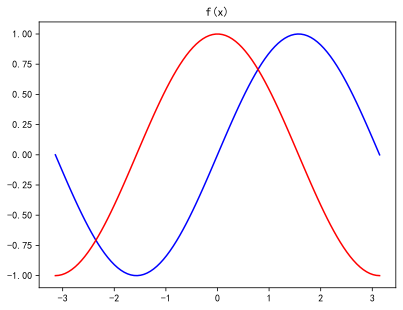

In [41]:
fg1,ax=plt.subplots()
ax.set_title('f(x)')
x=np.linspace(-np.pi,np.pi,100)
y_matrix=np.array([np.sin(x),np.cos(x)]).T
lines=ax.plot(x,y_matrix,color='red',)
lines[0].set_color('blue')